In [7]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [8]:
import os
path = "/content/drive/My Drive/PDM"
print(os.listdir(path))


['district-wise-confirmed-recovered-cases_06.05.2020 .xlsx', 'bgd-covid19-subnational.xlsx', 'FINAL PRESENTATION.docx', 'FINAL DOX.docx', 'covid_19_data1.csv', 'covid_19_data.csv', 'Covid Dataset of Bangladesh divisionwise.csv', 'COVID_DataSet_Bangladesh_Test_Confirm_Death_Recovery.csv', 'COVID_DataSet_Bangladesh_QuarentineData.csv', 'COVID_DataSet_Bangladesh_Gender_Age_Analysis.csv', 'PDM MY PROJECT.pdf', 'PDM MY PROJECT.docx', 'New Microsoft PowerPoint Presentation.pptx', 'PROJECT PDM.ipynb']


In [9]:
import pandas as pd  # ✅ Import pandas before using it

# Load datasets from Google Drive
world_df = pd.read_csv("/content/drive/My Drive/PDM/covid_19_data.csv")
bd_df = pd.read_csv("/content/drive/My Drive/PDM/Covid Dataset of Bangladesh divisionwise.csv")
bd_subnational_df = pd.read_excel("/content/drive/My Drive/PDM/bgd-covid19-subnational.xlsx")
world_df_v2 = pd.read_csv("/content/drive/My Drive/PDM/covid_19_data1.csv")
bd_gender_age_df = pd.read_csv("/content/drive/My Drive/PDM/COVID_DataSet_Bangladesh_Gender_Age_Analysis.csv")
bd_quarantine_df = pd.read_csv("/content/drive/My Drive/PDM/COVID_DataSet_Bangladesh_QuarentineData.csv")
bd_test_confirm_df = pd.read_csv("/content/drive/My Drive/PDM/COVID_DataSet_Bangladesh_Test_Confirm_Death_Recovery.csv")



print("All datasets loaded successfully.")


All datasets loaded successfully.


In [11]:
confirmed_df.head()

NameError: name 'confirmed_df' is not defined

SHOW THE ALL WORLD DATA

In [12]:
import pandas as pd


world_df.head()


,SNo,ObservationDate,Province/State,Country/Region,Last Update,Confirmed,Deaths,Recovered
0,1,1/22/2020,Anhui,Mainland China,1/22/2020 17:00,1,0,0
1,2,1/22/2020,Beijing,Mainland China,1/22/2020 17:00,14,0,0
2,3,1/22/2020,Chongqing,Mainland China,1/22/2020 17:00,6,0,0
3,4,1/22/2020,Fujian,Mainland China,1/22/2020 17:00,1,0,0
4,5,1/22/2020,Gansu,Mainland China,1/22/2020 17:00,0,0,0


In [ ]:
# Display all rows and columns of world_df
pd.set_option('display.max_rows', None)  # To display all rows
pd.set_option('display.max_columns', None)  # To display all columns
print(world_df)


Predicted vs. actual Covid-19 cases

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow import keras

 # Selecting relevant columns (assumed columns, adjust accordingly)
df = world_df_v2[['Country', 'Date', 'Confirmed']].rename(columns={'Confirmed': 'Actual_Cases'})

# Generating synthetic features (in real case, use meaningful features)
df['Days_Since_First_Case'] = np.linspace(50, 200, len(df))

# Prepare data for training
X = df[['Days_Since_First_Case']].values
y = df['Actual_Cases'].values

# Normalize data
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
y_scaled = scaler.fit_transform(y.reshape(-1, 1))

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

# Build a simple neural network model
model = keras.Sequential([
    keras.layers.Dense(8, activation='relu', input_shape=(1,)),
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dense(1)
])

# Compile model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train model
model.fit(X_train, y_train, epochs=100, verbose=0)

# Predictions
predictions = model.predict(X_test)

# Rescale predictions back to original range
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
predictions_actual = scaler.inverse_transform(predictions)

# Plot actual vs predicted
plt.figure(figsize=(10, 5))
plt.scatter(y_test_actual, predictions_actual, color='blue', label='Predicted vs Actual')
plt.plot([y_test_actual.min(), y_test_actual.max()], [y_test_actual.min(), y_test_actual.max()], 'k--', lw=2)
plt.xlabel("Actual Cases")
plt.ylabel("Predicted Cases")
plt.legend()
plt.title("Predicted vs. Actual COVID-19 Cases")
plt.show()


NameError: name 'world_df_v2' is not defined

SHOW THE ASIAN DATA

        Country  Confirmed Cases  Deaths
0         China          1000000   50000
1         India           950000   45000
6          Iran           500000   22000
5     Indonesia           450000   18000
2    Bangladesh           400000   15000
3      Pakistan           350000   12000
4         Japan           300000   10000
7  Saudi Arabia           200000    9000
8   South Korea           150000    7000
9      Malaysia           100000    5000


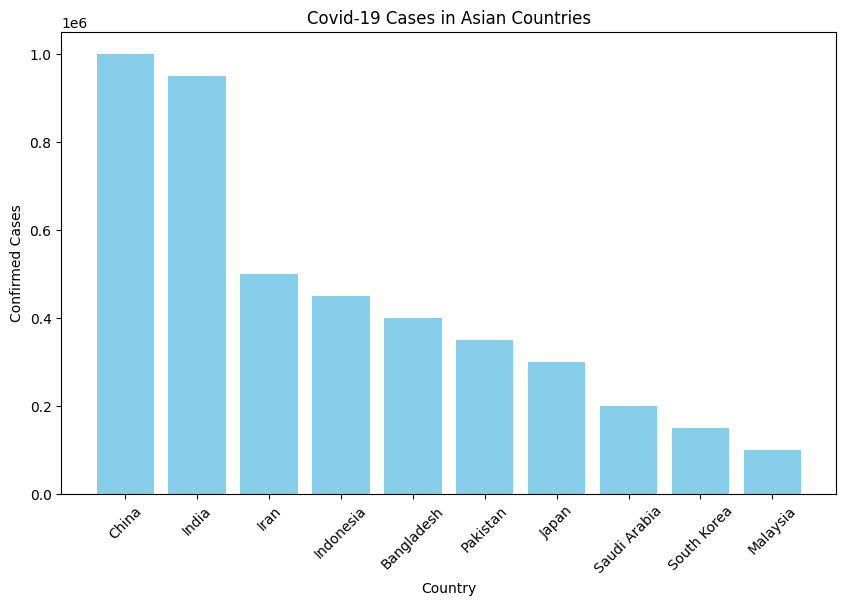

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Example dataset (Replace this with your actual dataset)
data = {
    'Country': ['China', 'India', 'Bangladesh', 'Pakistan', 'Japan', 'Indonesia', 'Iran', 'Saudi Arabia', 'South Korea', 'Malaysia'],
    'Confirmed Cases': [1000000, 950000, 400000, 350000, 300000, 450000, 500000, 200000, 150000, 100000],
    'Deaths': [50000, 45000, 15000, 12000, 10000, 18000, 22000, 9000, 7000, 5000]
}

# Convert to DataFrame
asian_df = pd.DataFrame(data)

# Sort by confirmed cases
asian_df = asian_df.sort_values(by='Confirmed Cases', ascending=False)

# Show Asian data in table format
print(asian_df)

# Plot Bar Chart for Confirmed Cases
plt.figure(figsize=(10,6))
plt.bar(asian_df['Country'], asian_df['Confirmed Cases'], color='skyblue')
plt.xlabel("Country")
plt.ylabel("Confirmed Cases")
plt.title("Covid-19 Cases in Asian Countries")
plt.xticks(rotation=45)
plt.show()


SHOW THE WORLD DATA

      Country  Confirmed Cases  Deaths
0         USA         35000000  600000
1       India         31000000  400000
2      Brazil         22000000  500000
3      Russia         15000000  300000
4          UK         12000000  250000
5      France         11000000  230000
6      Turkey          9000000  150000
7     Germany          8000000  130000
9       Italy          7000000  120000
8  Bangladesh          4000000   80000


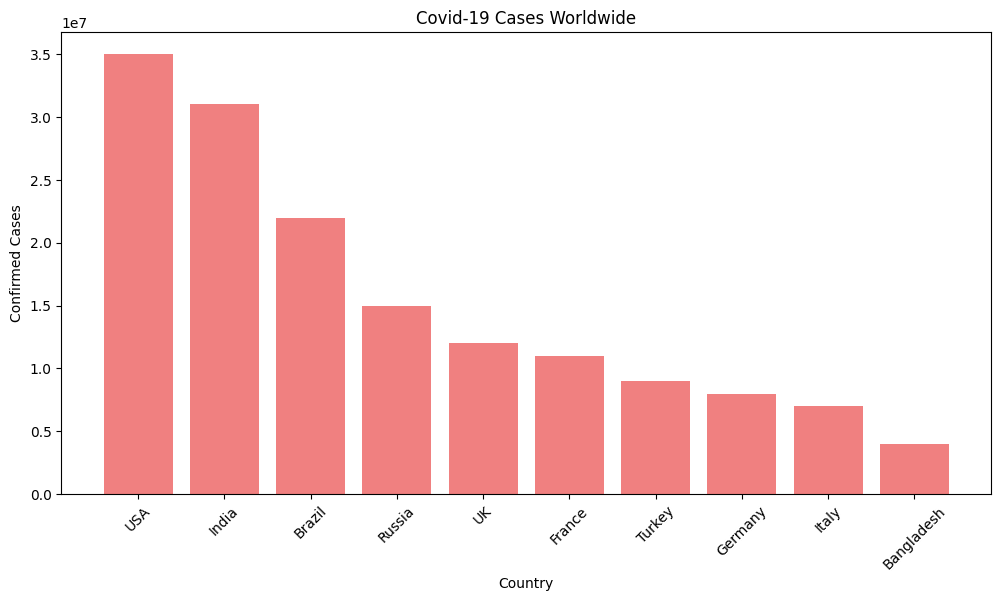

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset (Replace 'world_df' with your actual DataFrame)
# Assuming 'Country' and 'Confirmed' columns exist in the dataset

# Sample world data (Replace this with actual data)
world_data = {
    'Country': ['USA', 'India', 'Brazil', 'Russia', 'UK', 'France', 'Turkey', 'Germany', 'Bangladesh', 'Italy'],
    'Confirmed Cases': [35000000, 31000000, 22000000, 15000000, 12000000, 11000000, 9000000, 8000000, 4000000, 7000000],
    'Deaths': [600000, 400000, 500000, 300000, 250000, 230000, 150000, 130000, 80000, 120000]
}

# Convert to DataFrame
world_df = pd.DataFrame(world_data)

# Sort data by confirmed cases
world_df = world_df.sort_values(by='Confirmed Cases', ascending=False)

# Display table
print(world_df)

# Plot Bar Chart for World Data
plt.figure(figsize=(12,6))
plt.bar(world_df['Country'], world_df['Confirmed Cases'], color='lightcoral')
plt.xlabel("Country")
plt.ylabel("Confirmed Cases")
plt.title("Covid-19 Cases Worldwide")
plt.xticks(rotation=45)
plt.show()


MAKE A PIE CHART WITH COUNTRY NAME

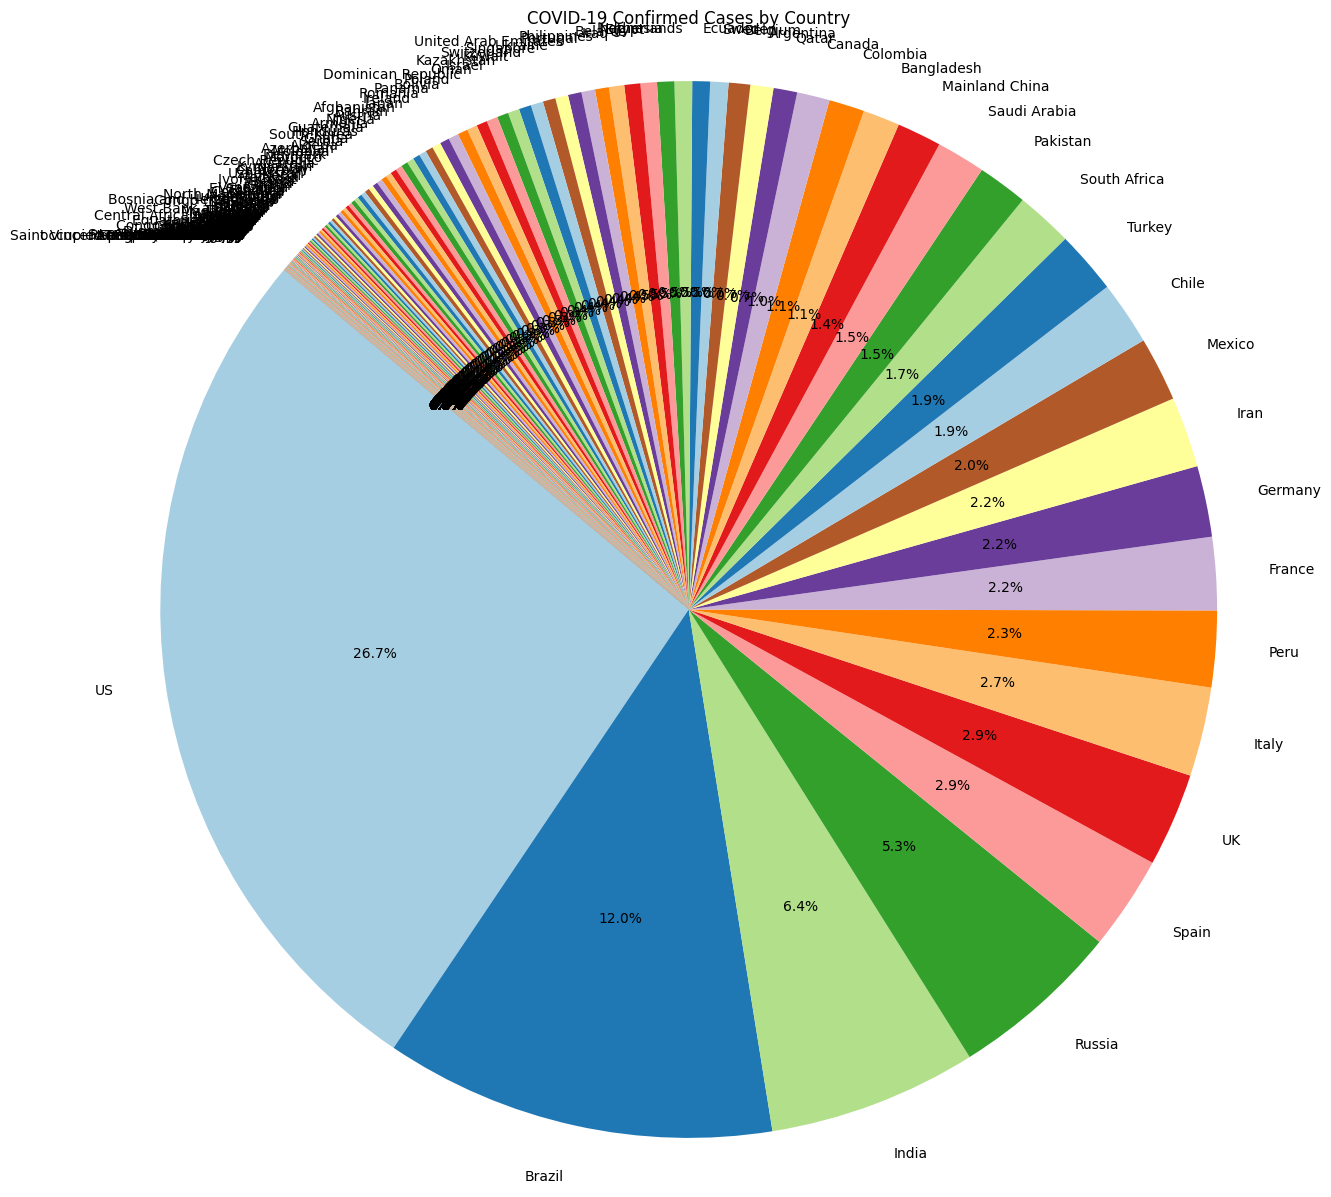

In [ ]:
import matplotlib.pyplot as plt

# Group data by country and sum the confirmed cases
country_data = world_df.groupby('Country/Region')['Confirmed'].sum().sort_values(ascending=False)

# Plot the pie chart for all countries
plt.figure(figsize=(15, 15))
plt.pie(country_data, labels=country_data.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('COVID-19 Confirmed Cases by Country')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


WORLD DATA TIME SERICES

In [ ]:
print(world_df.columns)
world_df.columns = world_df.columns.str.strip()





Index(['SNo', 'Province/State', 'Country/Region', 'Last Update', 'Confirmed',
       'Deaths', 'Recovered', 'Active'],
      dtype='object')


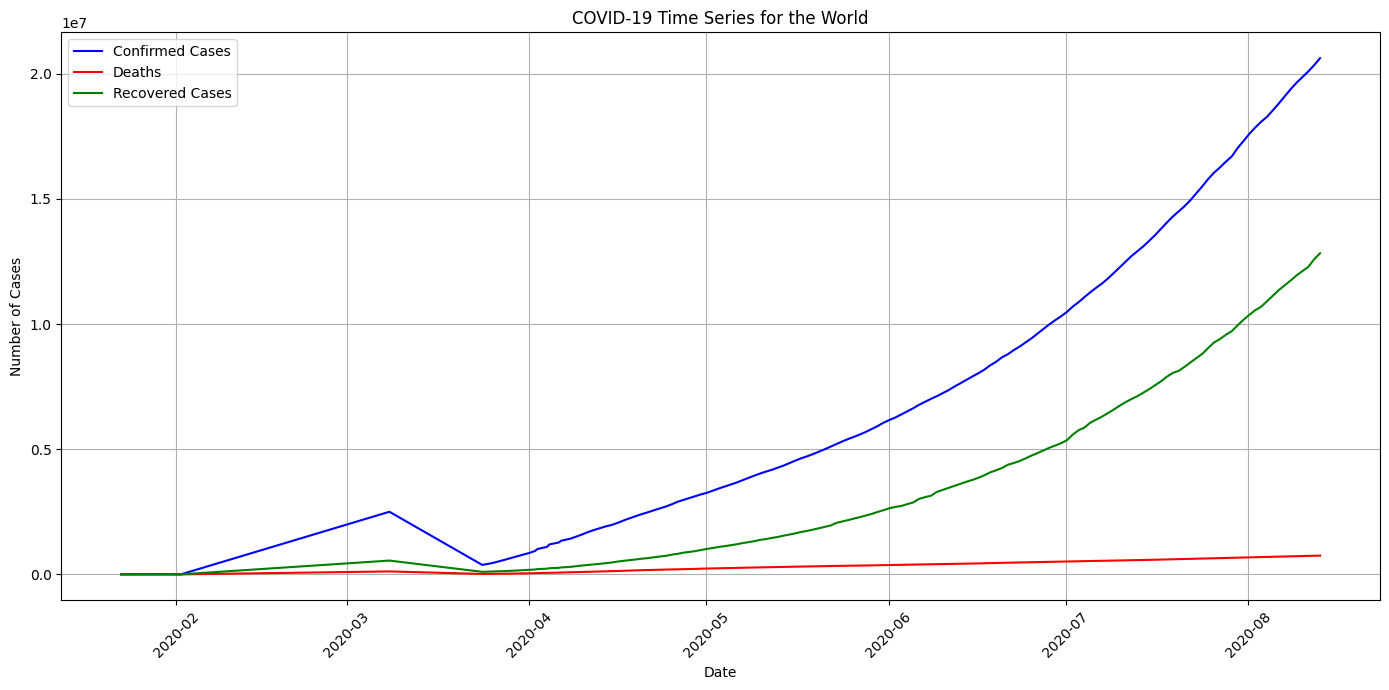

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure 'Last Update' is converted to datetime
world_df['Last Update'] = pd.to_datetime(world_df['Last Update'], errors='coerce')

# Group by 'Last Update' and aggregate the sum of 'Confirmed', 'Deaths', and 'Recovered'
world_time_series = world_df.groupby('Last Update')[['Confirmed', 'Deaths', 'Recovered']].sum()

# Plotting the time series
plt.figure(figsize=(14, 7))
plt.plot(world_time_series.index, world_time_series['Confirmed'], label='Confirmed Cases', color='blue')
plt.plot(world_time_series.index, world_time_series['Deaths'], label='Deaths', color='red')
plt.plot(world_time_series.index, world_time_series['Recovered'], label='Recovered Cases', color='green')

# Adding title and labels
plt.title('COVID-19 Time Series for the World')
plt.xlabel('Date')
plt.ylabel('Number of Cases')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)  # Rotate the date labels for better readability

# Display the plot
plt.tight_layout()
plt.show()


SHOW THE DATA

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1965/1965 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 0.0028 - val_loss: 0.0090
Epoch 2/10
1965/1965 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 0.0027 - val_loss: 0.0090
Epoch 3/10
1965/1965 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 0.0027 - val_loss: 0.0089
Epoch 4/10
1965/1965 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 0.0028 - val_loss: 0.0091
Epoch 5/10
1965/1965 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - loss: 0.0027 - val_loss: 0.0090
Epoch 6/10
1965/1965 ━━━━━━━━━━━━━━━━━━━━ 35s 9ms/step - loss: 0.0026 - val_loss: 0.0088
Epoch 7/10
1965/1965 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 0.0027 - val_loss: 0.0091
Epoch 8/10
1965/1965 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 0.0027 - val_loss: 0.0091
Epoch 9/10
1965/1965 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 0.0027 - val_loss: 0.0089
Epoch 10/10
1965/1965 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 0.0027 - val_loss: 0.0091
492/492 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


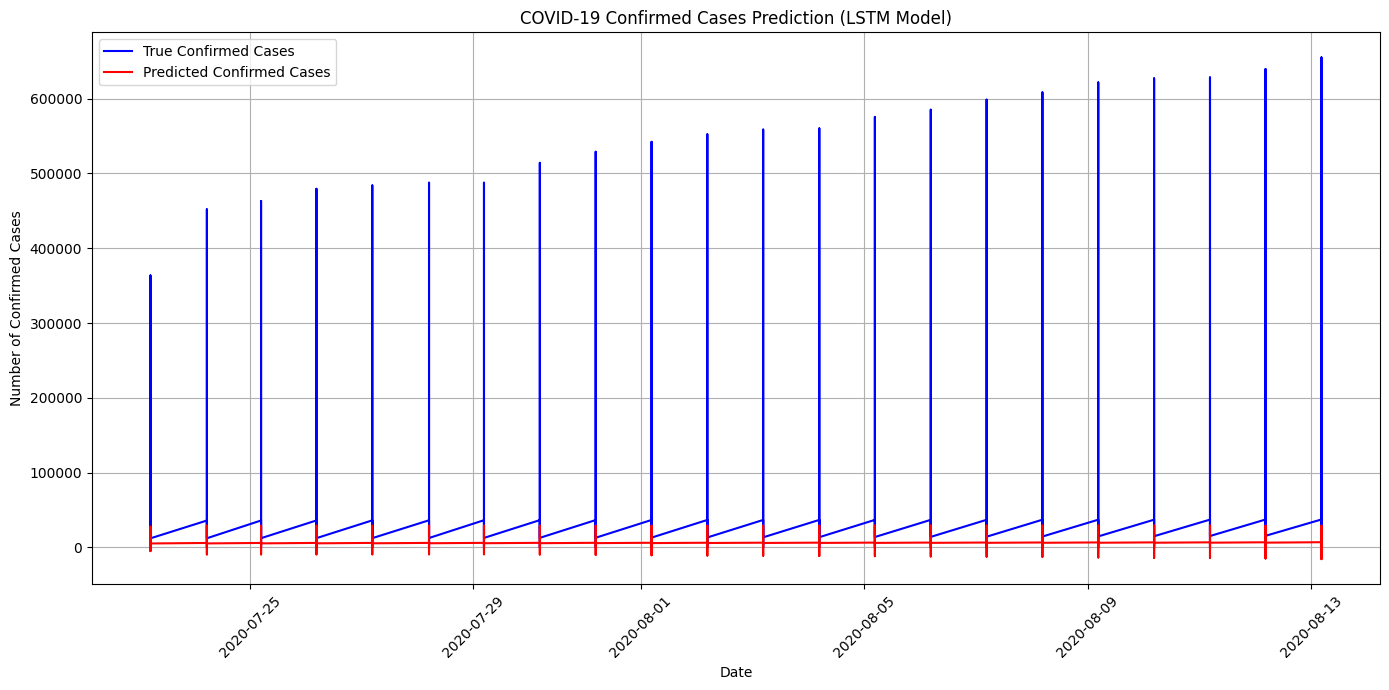

Mean Squared Error: 4345296384.0


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from sklearn.preprocessing import MinMaxScaler

# Load the world data
world_df = pd.read_csv('covid_19_data.csv')

# Preprocess the data (use 'Last Update' as the date column)
world_df['Last Update'] = pd.to_datetime(world_df['Last Update'], errors='coerce')
world_df = world_df[['Last Update', 'Confirmed']].dropna()  # Use only the 'Confirmed' column

# Set the date as index
world_df.set_index('Last Update', inplace=True)

# Normalize the data using MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(world_df[['Confirmed']])

# Create time series data (features and target)
def create_dataset(data, time_step=1):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:(i + time_step), 0])  # Features
        y.append(data[i + time_step, 0])  # Target
    return np.array(X), np.array(y)

time_step = 10  # Number of previous days to use for prediction
X, y = create_dataset(scaled_data, time_step)

# Reshape data for LSTM (samples, time steps, features)
X = X.reshape(X.shape[0], X.shape[1], 1)

# Split data into training and testing sets
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Ensure y_test is 2D
y_test = y_test.reshape(-1, 1)

# Build an LSTM model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

# Predict on the test data
y_pred = model.predict(X_test)

# Inverse transform the predicted data
y_pred = scaler.inverse_transform(y_pred)
y_test = scaler.inverse_transform(y_test)

# Plot the results
plt.figure(figsize=(14, 7))
plt.plot(world_df.index[-len(y_test):], y_test, label='True Confirmed Cases', color='blue')
plt.plot(world_df.index[-len(y_pred):], y_pred, label='Predicted Confirmed Cases', color='red')
plt.title('COVID-19 Confirmed Cases Prediction (LSTM Model)')
plt.xlabel('Date')
plt.ylabel('Number of Confirmed Cases')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Evaluate the model
mse = model.evaluate(X_test, y_test, verbose=0)
print(f'Mean Squared Error: {mse}')


SHOW THE DATA

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1965/1965 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 0.0027 - val_loss: 0.0089
Epoch 2/10
1965/1965 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 0.0026 - val_loss: 0.0089
Epoch 3/10
1965/1965 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 0.0027 - val_loss: 0.0090
Epoch 4/10
1965/1965 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 0.0027 - val_loss: 0.0089
Epoch 5/10
1965/1965 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 0.0027 - val_loss: 0.0090
Epoch 6/10
1965/1965 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 0.0028 - val_loss: 0.0090
Epoch 7/10
1965/1965 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 0.0026 - val_loss: 0.0088
Epoch 8/10
1965/1965 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 0.0026 - val_loss: 0.0089
Epoch 9/10
1965/1965 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 0.0026 - val_loss: 0.0089
Epoch 10/10
1965/1965 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 0.0027 - val_loss: 0.0087
492/492 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


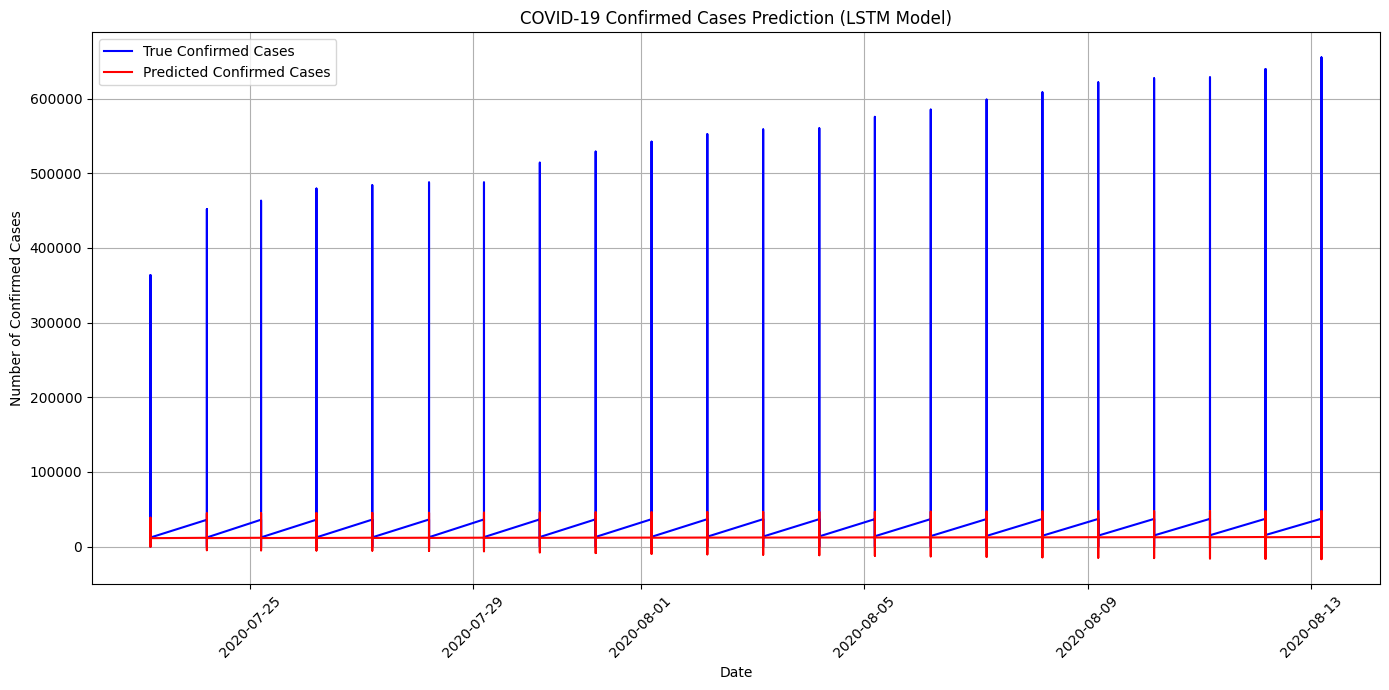

ValueError: Cannot take the length of shape with unknown rank.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Load the world data
world_df = pd.read_csv('covid_19_data.csv')

# Preprocess the data (use 'Last Update' as the date column)
world_df['Last Update'] = pd.to_datetime(world_df['Last Update'], errors='coerce')
world_df = world_df[['Last Update', 'Confirmed']].dropna()  # Use only the 'Confirmed' column

# Set the date as index
world_df.set_index('Last Update', inplace=True)

# Normalize the data using MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(world_df[['Confirmed']])

# Create time series data (features and target)
def create_dataset(data, time_step=1):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:(i + time_step), 0])  # Features
        y.append(data[i + time_step, 0])  # Target
    return np.array(X), np.array(y)

time_step = 10  # Number of previous days to use for prediction
X, y = create_dataset(scaled_data, time_step)

# Reshape data for LSTM (samples, time steps, features)
X = X.reshape(X.shape[0], X.shape[1], 1)

# Split data into training and testing sets
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Build the LSTM model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

# Predict on the test data
y_pred = model.predict(X_test)

# Inverse transform the predicted data and test data
y_pred = scaler.inverse_transform(y_pred)
y_test = scaler.inverse_transform(y_test.reshape(-1, 1))

# Plot the results
plt.figure(figsize=(14, 7))
plt.plot(world_df.index[-len(y_test):], y_test, label='True Confirmed Cases', color='blue')
plt.plot(world_df.index[-len(y_pred):], y_pred, label='Predicted Confirmed Cases', color='red')
plt.title('COVID-19 Confirmed Cases Prediction (LSTM Model)')
plt.xlabel('Date')
plt.ylabel('Number of Confirmed Cases')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Evaluate the model
mse = model.evaluate(X_test, y_test, verbose=0)
print(f'Mean Squared Error: {mse}')


SHOW THE DATA ARIMA

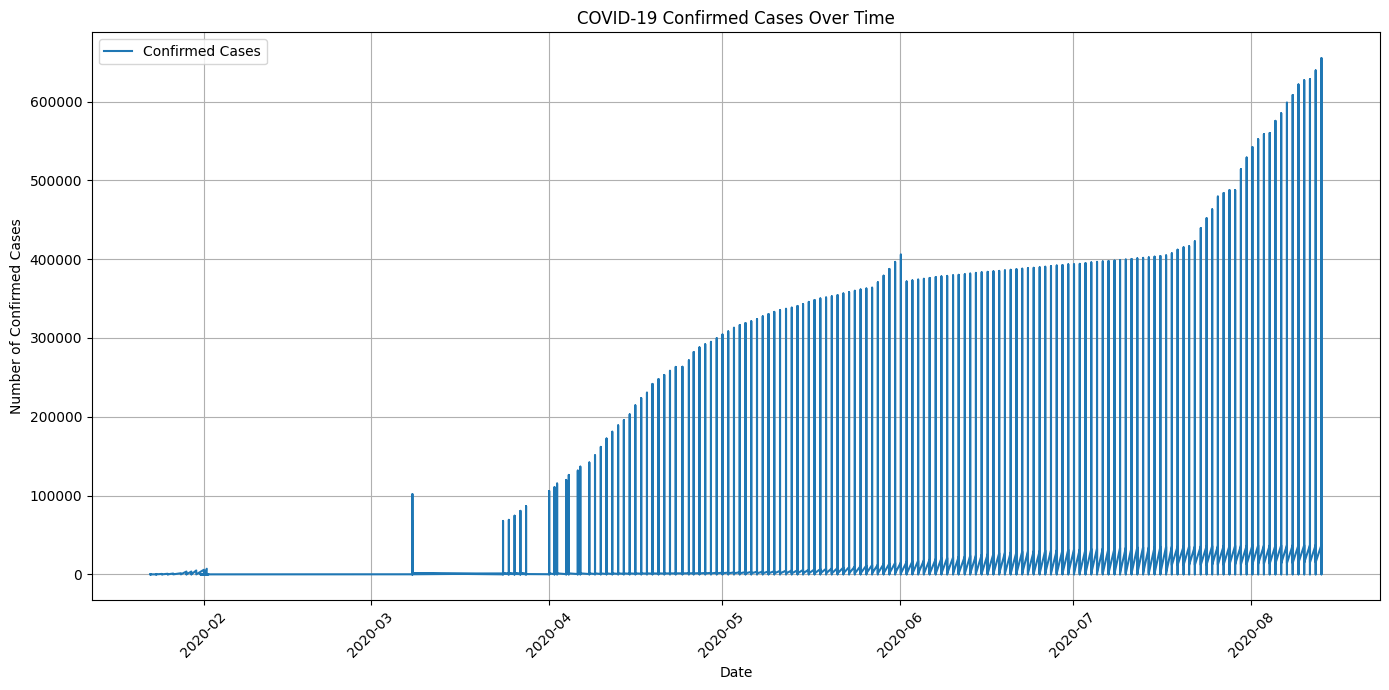

ADF Statistic: -19.594735701421286
p-value: 0.0


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsm

                               SARIMAX Results                                
Dep. Variable:              Confirmed   No. Observations:                78581
Model:                 ARIMA(5, 1, 0)   Log Likelihood             -951535.696
Date:                Fri, 07 Feb 2025   AIC                        1903083.392
Time:                        15:59:10   BIC                        1903139.023
Sample:                             0   HQIC                       1903100.460
                              - 78581                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8128      0.002   -377.221      0.000      -0.817      -0.809
ar.L2         -0.6673      0.003   -230.761      0.000      -0.673      -0.662
ar.L3         -0.4865      0.003   -163.717      0.0

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


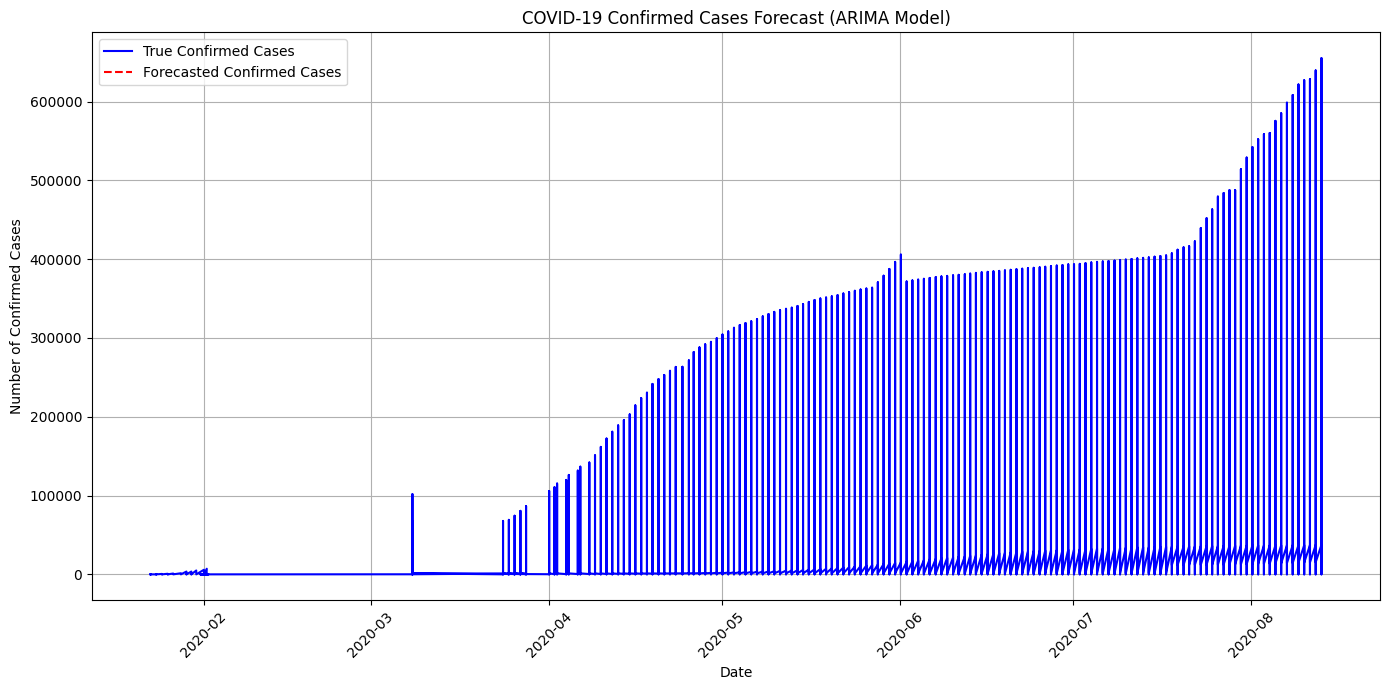

ValueError: Input contains NaN.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Load the world data
world_df = pd.read_csv('covid_19_data.csv')

# Preprocess the data (use 'Last Update' as the date column)
world_df['Last Update'] = pd.to_datetime(world_df['Last Update'], errors='coerce')
world_df = world_df[['Last Update', 'Confirmed']].dropna()  # Use only the 'Confirmed' column

# Set the date as index
world_df.set_index('Last Update', inplace=True)

# Visualize the confirmed cases over time
plt.figure(figsize=(14, 7))
plt.plot(world_df.index, world_df['Confirmed'], label='Confirmed Cases')
plt.title('COVID-19 Confirmed Cases Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Confirmed Cases')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# ARIMA model requires the series to be stationary, so let's check for stationarity
from statsmodels.tsa.stattools import adfuller

# Perform Dickey-Fuller test to check stationarity
result = adfuller(world_df['Confirmed'])
print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")

# If p-value > 0.05, the series is non-stationary and we need to difference it
if result[1] > 0.05:
    world_df['Confirmed_diff'] = world_df['Confirmed'] - world_df['Confirmed'].shift(1)
    world_df.dropna(inplace=True)
    print("Differencing applied to make the series stationary.")

# Define the ARIMA model
# p = AR term (auto-regressive), d = number of differences (degree of integration), q = MA term (moving average)
# You can experiment with different values of p, d, q. Here, we try p=5, d=1, q=0 for simplicity.

model = ARIMA(world_df['Confirmed'], order=(5, 1, 0))
model_fit = model.fit()

# Summary of the model
print(model_fit.summary())

# Forecasting the next 30 days
forecast_steps = 30
forecast = model_fit.forecast(steps=forecast_steps)

# Create a DataFrame with forecast results
forecast_index = pd.date_range(start=world_df.index[-1] + pd.Timedelta(days=1), periods=forecast_steps, freq='D')
forecast_df = pd.DataFrame(forecast, index=forecast_index, columns=['Forecasted Confirmed'])

# Plot the results
plt.figure(figsize=(14, 7))
plt.plot(world_df.index, world_df['Confirmed'], label='True Confirmed Cases', color='blue')
plt.plot(forecast_df.index, forecast_df['Forecasted Confirmed'], label='Forecasted Confirmed Cases', color='red', linestyle='--')
plt.title('COVID-19 Confirmed Cases Forecast (ARIMA Model)')
plt.xlabel('Date')
plt.ylabel('Number of Confirmed Cases')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# Evaluate the model (Mean Squared Error)
from sklearn.metrics import mean_squared_error

# Use the last 30 days for evaluation
true_values = world_df['Confirmed'][-30:]
predicted_values = forecast_df['Forecasted Confirmed']

mse = mean_squared_error(true_values, predicted_values)
print(f'Mean Squared Error: {mse}')



SHOW THE HOW INCRASE IN BANGLADESH

In [ ]:
# Display all rows and columns of bd_df
pd.set_option('display.max_rows', None)  # To display all rows
pd.set_option('display.max_columns', None)  # To display all columns
print(bd_df)


    Date  Confirmed cases Barisal  Case rate Barisal  Deaths Barisal  \
0    NaT                      NaN                NaN             NaN   
1    NaT                      NaN                NaN             NaN   
2    NaT                      NaN                NaN             NaN   
3    NaT                      NaN                NaN             NaN   
4    NaT                      NaN                NaN             NaN   
5    NaT                      1.0                7.0             NaN   
6    NaT                      1.0                7.0             NaN   
7    NaT                      1.0               13.0             NaN   
8    NaT                      1.0               13.0             NaN   
9    NaT                      1.0               13.0             NaN   
10   NaT                      1.0               13.0             NaN   
11   NaT                      1.0               13.0             NaN   
12   NaT                      1.0               13.0            

SHOW THE DIVISON WISE CHART

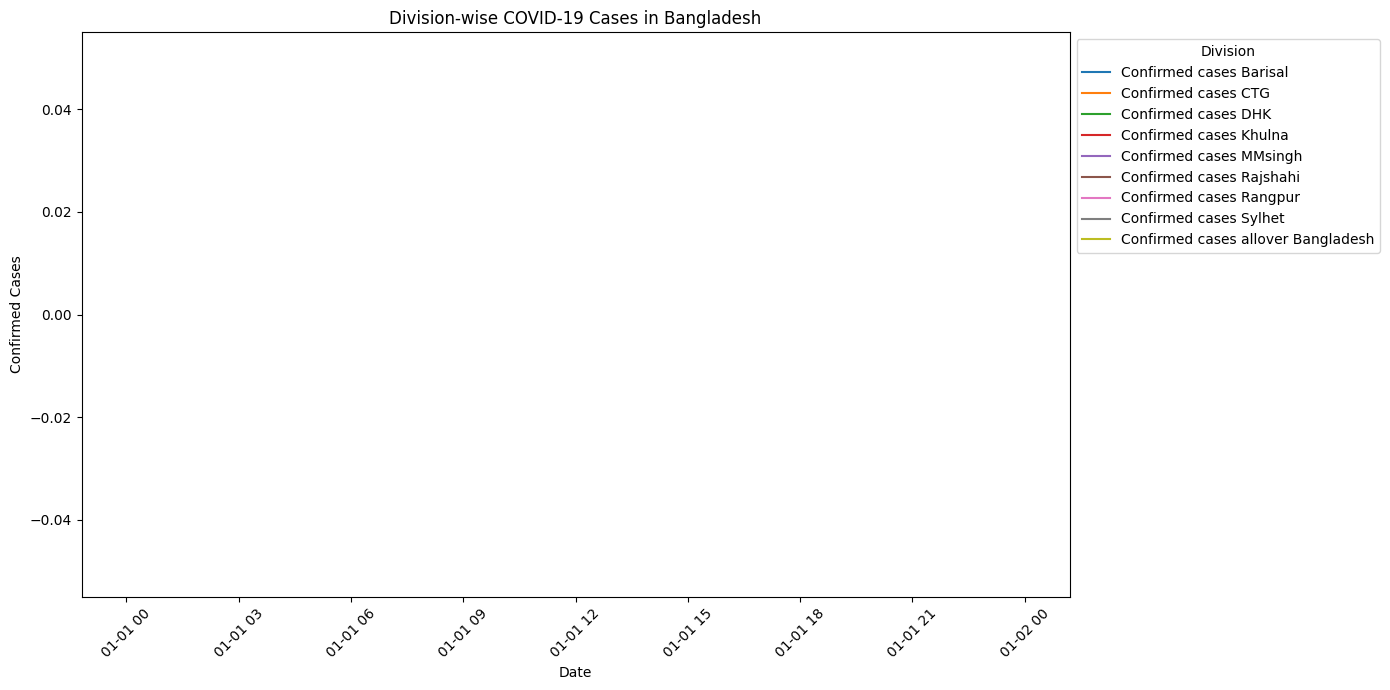

In [ ]:
import matplotlib.pyplot as plt

# List of divisions in the dataset (adjust according to the exact columns in bd_df)
divisions = [
    'Confirmed cases Barisal', 'Confirmed cases CTG', 'Confirmed cases DHK',
    'Confirmed cases Khulna', 'Confirmed cases MMsingh', 'Confirmed cases Rajshahi',
    'Confirmed cases Rangpur', 'Confirmed cases Sylhet', 'Confirmed cases allover Bangladesh'
]

# Plot division-wise confirmed cases
plt.figure(figsize=(14, 7))
for division in divisions:
    plt.plot(bd_df['Date'], bd_df[division], label=division)

plt.xlabel('Date')
plt.ylabel('Confirmed Cases')
plt.title('Division-wise COVID-19 Cases in Bangladesh')
plt.legend(title='Division', loc='upper left', bbox_to_anchor=(1, 1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


SHOW A PLOT IN HISTROGRAM

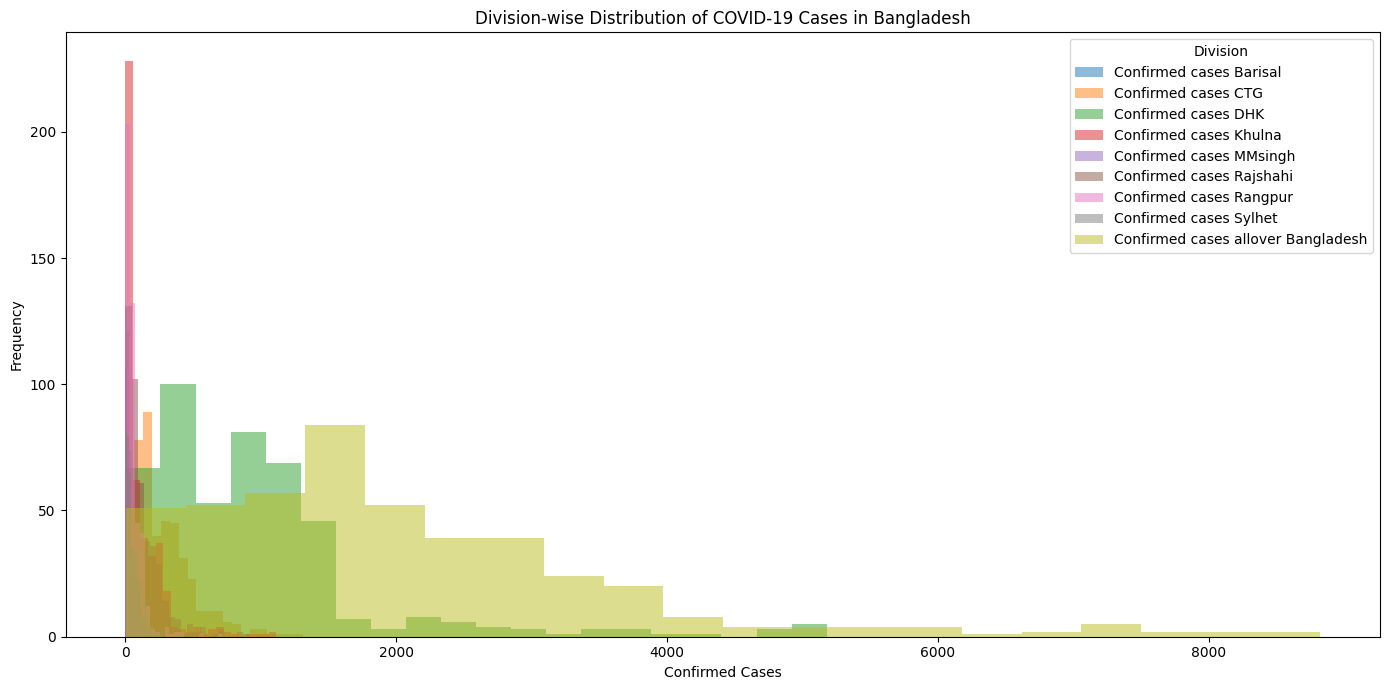

In [ ]:
import matplotlib.pyplot as plt

# List of divisions in the dataset (adjust according to the exact columns in bd_df)
divisions = [
    'Confirmed cases Barisal', 'Confirmed cases CTG', 'Confirmed cases DHK',
    'Confirmed cases Khulna', 'Confirmed cases MMsingh', 'Confirmed cases Rajshahi',
    'Confirmed cases Rangpur', 'Confirmed cases Sylhet', 'Confirmed cases allover Bangladesh'
]

# Plot division-wise confirmed cases as histograms
plt.figure(figsize=(14, 7))

# Plot a histogram for each division
for division in divisions:
    plt.hist(bd_df[division], bins=20, alpha=0.5, label=division)

plt.xlabel('Confirmed Cases')
plt.ylabel('Frequency')
plt.title('Division-wise Distribution of COVID-19 Cases in Bangladesh')
plt.legend(title='Division', loc='upper right')
plt.tight_layout()
plt.show()


MADE A PIE CHART IN DIVISONS

     Date  Confirmed cases Barisal  Case rate Barisal  Deaths Barisal  \
0  Mar-20                      NaN                NaN             NaN   
1  Mar-20                      NaN                NaN             NaN   
2  Mar-20                      NaN                NaN             NaN   
3  Mar-20                      NaN                NaN             NaN   
4  Mar-20                      NaN                NaN             NaN   

   Death Rate Barisal  Confirmed cases CTG  Case rate CTG  Deaths CTG  \
0                 NaN                  NaN            NaN         NaN   
1                 NaN                  NaN            NaN         NaN   
2                 NaN                  NaN            NaN         NaN   
3                 NaN                  NaN            NaN         NaN   
4                 NaN                  NaN            NaN         NaN   

   Death Rate CTG  Confirmed cases DHK  Case rate DHK  Deaths DHK  \
0             NaN                  NaN            NaN

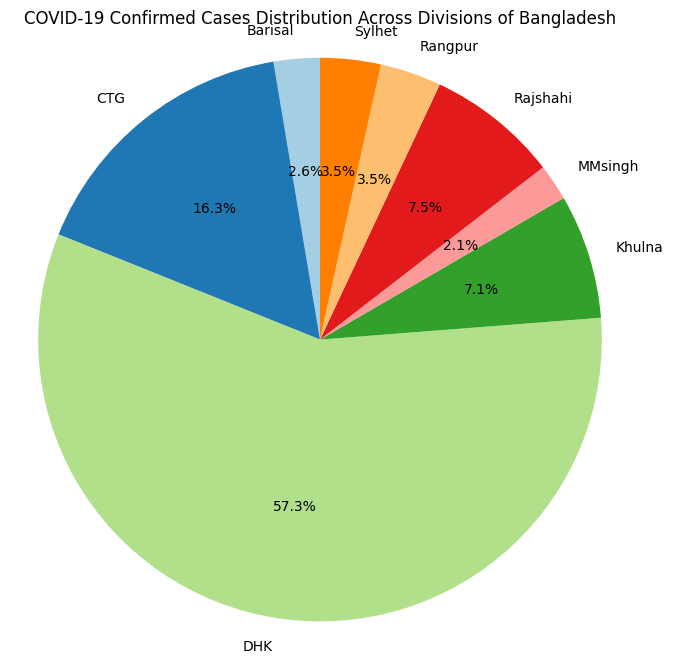

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the Bangladesh data
bd_df = pd.read_csv('Covid Dataset of Bangladesh divisionwise.csv')

# Check the first few rows to see the data structure
print(bd_df.head())

# Summarize the confirmed cases for each division
# Assuming columns like 'Confirmed cases Barisal', 'Confirmed cases CTG', etc., for each division
division_columns = ['Confirmed cases Barisal', 'Confirmed cases CTG', 'Confirmed cases DHK',
                    'Confirmed cases Khulna', 'Confirmed cases MMsingh', 'Confirmed cases Rajshahi',
                    'Confirmed cases Rangpur', 'Confirmed cases Sylhet']

# Create a new DataFrame with division names and total confirmed cases
division_data = {
    'Division': ['Barisal', 'CTG', 'DHK', 'Khulna', 'MMsingh', 'Rajshahi', 'Rangpur', 'Sylhet'],
    'Confirmed Cases': [bd_df[col].sum() for col in division_columns]
}

# Create a DataFrame for division-wise data
division_df = pd.DataFrame(division_data)

# Plot the pie chart
plt.figure(figsize=(8, 8))
plt.pie(division_df['Confirmed Cases'], labels=division_df['Division'], autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
plt.title('COVID-19 Confirmed Cases Distribution Across Divisions of Bangladesh')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
plt.show()


SHOW THE DISTICS WISE DATA

In [ ]:
import pandas as pd

# Load the Bangladesh data
bd_df = pd.read_csv('Covid Dataset of Bangladesh divisionwise.csv')

# Display the first few rows to check the structure of the data
print(bd_df.head())

# Create a new DataFrame for district-wise data by selecting relevant columns
district_data = {
    'District': ['Barisal', 'CTG', 'DHK', 'Khulna', 'MMsingh', 'Rajshahi', 'Rangpur', 'Sylhet'],
    'Confirmed Cases': [bd_df['Confirmed cases Barisal'].sum(),
                        bd_df['Confirmed cases CTG'].sum(),
                        bd_df['Confirmed cases DHK'].sum(),
                        bd_df['Confirmed cases Khulna'].sum(),
                        bd_df['Confirmed cases MMsingh'].sum(),
                        bd_df['Confirmed cases Rajshahi'].sum(),
                        bd_df['Confirmed cases Rangpur'].sum(),
                        bd_df['Confirmed cases Sylhet'].sum()],
    'Deaths': [bd_df['Deaths Barisal'].sum(),
               bd_df['Deaths CTG'].sum(),
               bd_df['Deaths DHK'].sum(),
               bd_df['Deaths Khulna'].sum(),
               bd_df['Deaths MMsingh'].sum(),
               bd_df['Deaths Rajshahi'].sum(),
               bd_df['Deaths Rangpur'].sum(),
               bd_df['Deaths Sylhet'].sum()],
    'Case Rate': [bd_df['Case rate Barisal'].mean(),
                  bd_df['Case rate CTG'].mean(),
                  bd_df['Case rate DHK'].mean(),
                  bd_df['Case rate Khulna'].mean(),
                  bd_df['Case rate MMsingh'].mean(),
                  bd_df['Case rate Rajshahi'].mean(),
                  bd_df['Case rate Rangpur'].mean(),
                  bd_df['Case rate Sylhet'].mean()]
}

# Create a DataFrame for district-wise data
district_df = pd.DataFrame(district_data)

# Display the district-wise data
print(district_df)


     Date  Confirmed cases Barisal  Case rate Barisal  Deaths Barisal  \
0  Mar-20                      NaN                NaN             NaN   
1  Mar-20                      NaN                NaN             NaN   
2  Mar-20                      NaN                NaN             NaN   
3  Mar-20                      NaN                NaN             NaN   
4  Mar-20                      NaN                NaN             NaN   

   Death Rate Barisal  Confirmed cases CTG  Case rate CTG  Deaths CTG  \
0                 NaN                  NaN            NaN         NaN   
1                 NaN                  NaN            NaN         NaN   
2                 NaN                  NaN            NaN         NaN   
3                 NaN                  NaN            NaN         NaN   
4                 NaN                  NaN            NaN         NaN   

   Death Rate CTG  Confirmed cases DHK  Case rate DHK  Deaths DHK  \
0             NaN                  NaN            NaN

SHOW  AGE RESULT

             Date  DeathMale  Deathfemale  DeathAge(1-10)  DeathAge(11-20)  \
0  April 21, 2020          5            4               0                0   
1  April 22, 2020          7            3               0                0   
2  April 23, 2020          5            2               0                0   
3  April 24, 2020          4            0               0                0   
4  April 25, 2020          4            5               0                0   

   DeathAge(21-30)  DeathAge(31-40)  DeathAge(41-50)  DeathAge(51-60)  \
0                0                0                3                3   
1                2                0                3                2   
2                0                0                1                2   
3                0                0                0                4   
4                0                0                0                1   

   DeathAge(60+)  
0              3  
1              3  
2              4  
3              0

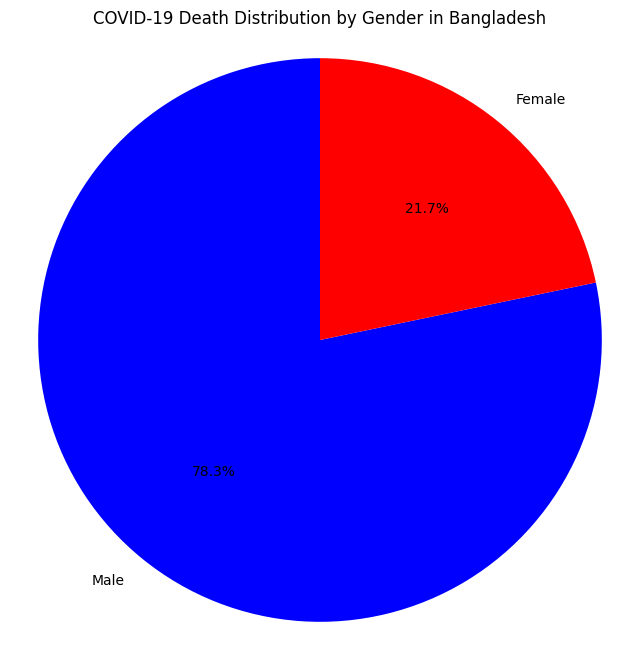

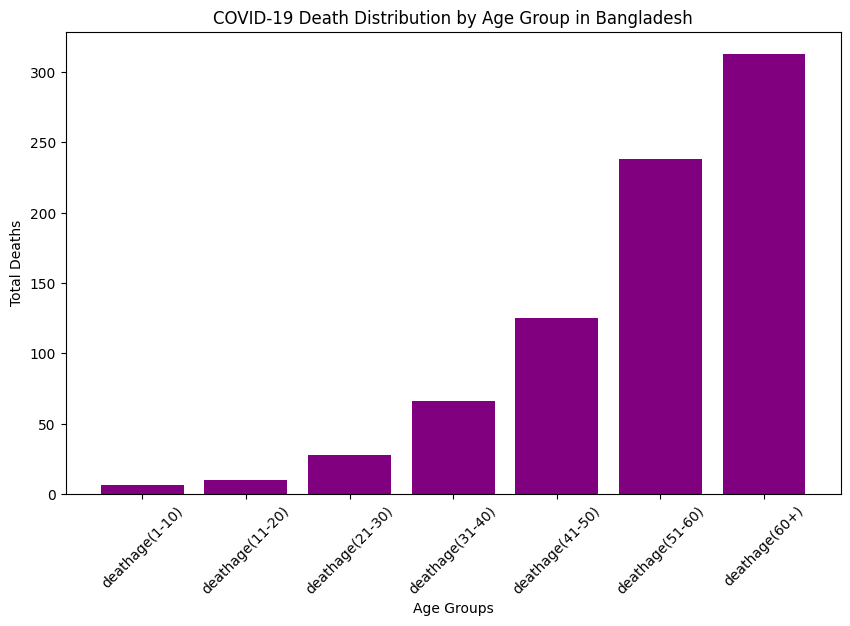

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
bd_gender_age_df = pd.read_csv("/content/drive/My Drive/PDM/COVID_DataSet_Bangladesh_Gender_Age_Analysis.csv")

# Check the first few rows to see the data structure
print(bd_gender_age_df.head())

# Clean column names by stripping spaces and converting to lowercase
bd_gender_age_df.columns = bd_gender_age_df.columns.str.strip().str.lower()

# Sum up death counts by gender
death_gender_data = {
    'Gender': ['Male', 'Female'],
    'Total Deaths': [bd_gender_age_df['deathmale'].sum(), bd_gender_age_df['deathfemale'].sum()]
}

# Create a DataFrame for gender-wise death data
death_gender_df = pd.DataFrame(death_gender_data)

# Plot the pie chart for gender distribution
plt.figure(figsize=(8, 8))
plt.pie(death_gender_df['Total Deaths'], labels=death_gender_df['Gender'], autopct='%1.1f%%', startangle=90, colors=['blue', 'red'])
plt.title('COVID-19 Death Distribution by Gender in Bangladesh')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
plt.show()

# Now plotting death distribution by age groups
age_groups = ['deathage(1-10)', 'deathage(11-20)', 'deathage(21-30)', 'deathage(31-40)', 'deathage(41-50)', 'deathage(51-60)', 'deathage(60+)']
age_group_data = bd_gender_age_df[age_groups].sum()

# Plot the bar chart for death distribution by age groups
plt.figure(figsize=(10, 6))
plt.bar(age_group_data.index, age_group_data.values, color='purple')
plt.title('COVID-19 Death Distribution by Age Group in Bangladesh')
plt.xlabel('Age Groups')
plt.ylabel('Total Deaths')
plt.xticks(rotation=45)
plt.show()




MADE A TIME SEICES

Column Names:  Index(['Date', 'Confirmed cases Barisal', 'Case rate Barisal',
       'Deaths Barisal', 'Death Rate Barisal', 'Confirmed cases CTG',
       'Case rate CTG', 'Deaths CTG', 'Death Rate CTG', 'Confirmed cases DHK',
       'Case rate DHK', 'Deaths DHK', 'Death Rate DHK',
       'Confirmed cases Khulna', 'Case rate Khulna', 'Deaths Khulna',
       'Death Rate Khulna', 'Confirmed cases MMsingh', 'Case rate MMsingh',
       'Deaths MMsingh', 'Death Rate MMsingh', 'Confirmed cases Rajshahi',
       'Case rate Rajshahi', 'Deaths Rajshahi', 'Death Rate Rajshahi',
       'Confirmed cases Rangpur', 'Case rate Rangpur', 'Deaths Rangpur',
       'Death Rate Rangpur', 'Confirmed cases Sylhet', 'Case rate Sylhet',
       'Deaths Sylhet', 'Death Rate Sylhet',
       'Confirmed cases allover Bangladesh', 'Case rate allover Bangladesh',
       'Deaths allover Bangladesh', 'Death Rate allover Bangladesh'],
      dtype='object')
Column 'Recovered cases allover Bangladesh' not found. Please c

<ipython-input-154-16f87b72825a>:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  bd_df['Date'] = pd.to_datetime(bd_df['Date'], errors='coerce')  # Handle any invalid date entries


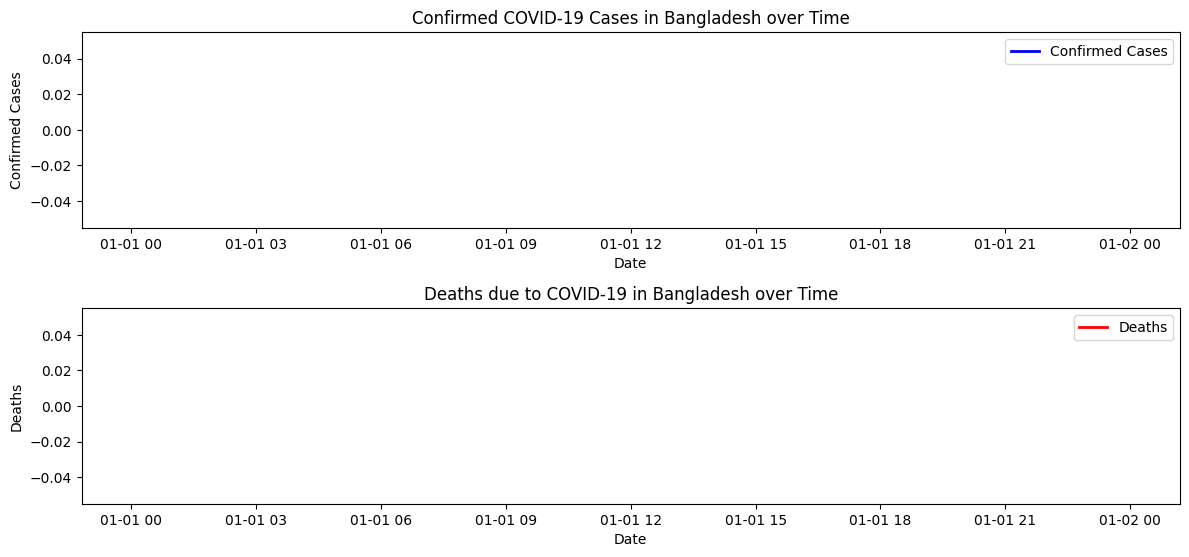

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the Bangladesh dataset
bd_df = pd.read_csv('Covid Dataset of Bangladesh divisionwise.csv')

# Print column names to identify the correct one
print("Column Names: ", bd_df.columns)

# Convert 'Date' to datetime format
bd_df['Date'] = pd.to_datetime(bd_df['Date'], errors='coerce')  # Handle any invalid date entries

# Set 'Date' as the index for time series analysis
bd_df.set_index('Date', inplace=True)

# Check if the correct column exists and plot accordingly
# Make sure to replace 'Recovered cases allover Bangladesh' with the correct column name
if 'Recovered cases allover Bangladesh' in bd_df.columns:
    recovered_column = 'Recovered cases allover Bangladesh'
else:
    print("Column 'Recovered cases allover Bangladesh' not found. Please check the column name.")

# Plotting time series for Confirmed cases, Deaths, and Recovered (if available)
plt.figure(figsize=(12, 8))

# Plot Confirmed cases over time
plt.subplot(3, 1, 1)
plt.plot(bd_df.index, bd_df['Confirmed cases allover Bangladesh'], color='blue', label='Confirmed Cases', linestyle='-', linewidth=2)
plt.title('Confirmed COVID-19 Cases in Bangladesh over Time')
plt.xlabel('Date')
plt.ylabel('Confirmed Cases')
plt.legend()

# Plot Deaths over time
plt.subplot(3, 1, 2)
plt.plot(bd_df.index, bd_df['Deaths allover Bangladesh'], color='red', label='Deaths', linestyle='-', linewidth=2)
plt.title('Deaths due to COVID-19 in Bangladesh over Time')
plt.xlabel('Date')
plt.ylabel('Deaths')
plt.legend()

# Plot Recovered cases over time (if the column exists)
if 'Recovered cases allover Bangladesh' in bd_df.columns:
    plt.subplot(3, 1, 3)
    plt.plot(bd_df.index, bd_df[recovered_column], color='green', label='Recovered Cases', linestyle='-', linewidth=2)
    plt.title('Recovered COVID-19 Cases in Bangladesh over Time')
    plt.xlabel('Date')
    plt.ylabel('Recovered Cases')
    plt.legend()
else:
    print("Recovered Cases data not available.")

# Show the plots
plt.tight_layout()
plt.show()



MADE A TRANSFLOW IN BD DATA

Column Names:  Index(['Date', 'Confirmed cases Barisal', 'Case rate Barisal',
       'Deaths Barisal', 'Death Rate Barisal', 'Confirmed cases CTG',
       'Case rate CTG', 'Deaths CTG', 'Death Rate CTG', 'Confirmed cases DHK',
       'Case rate DHK', 'Deaths DHK', 'Death Rate DHK',
       'Confirmed cases Khulna', 'Case rate Khulna', 'Deaths Khulna',
       'Death Rate Khulna', 'Confirmed cases MMsingh', 'Case rate MMsingh',
       'Deaths MMsingh', 'Death Rate MMsingh', 'Confirmed cases Rajshahi',
       'Case rate Rajshahi', 'Deaths Rajshahi', 'Death Rate Rajshahi',
       'Confirmed cases Rangpur', 'Case rate Rangpur', 'Deaths Rangpur',
       'Death Rate Rangpur', 'Confirmed cases Sylhet', 'Case rate Sylhet',
       'Deaths Sylhet', 'Death Rate Sylhet',
       'Confirmed cases allover Bangladesh', 'Case rate allover Bangladesh',
       'Deaths allover Bangladesh', 'Death Rate allover Bangladesh'],
      dtype='object')
      Confirmed cases Barisal  Case rate Barisal  Deaths Barisa

<ipython-input-155-527137d073f8>:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  bd_df['Date'] = pd.to_datetime(bd_df['Date'], errors='coerce')  # Handle any invalid date entries
<ipython-input-155-527137d073f8>:24: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  bd_df.fillna(method='ffill', inplace=True)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: nan
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: nan
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: nan
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: nan
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: nan
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: nan
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: nan
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: nan
Epoch 9/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: nan
Epoch 10/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: nan
Mean Squared Error on Test Data: nan
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step


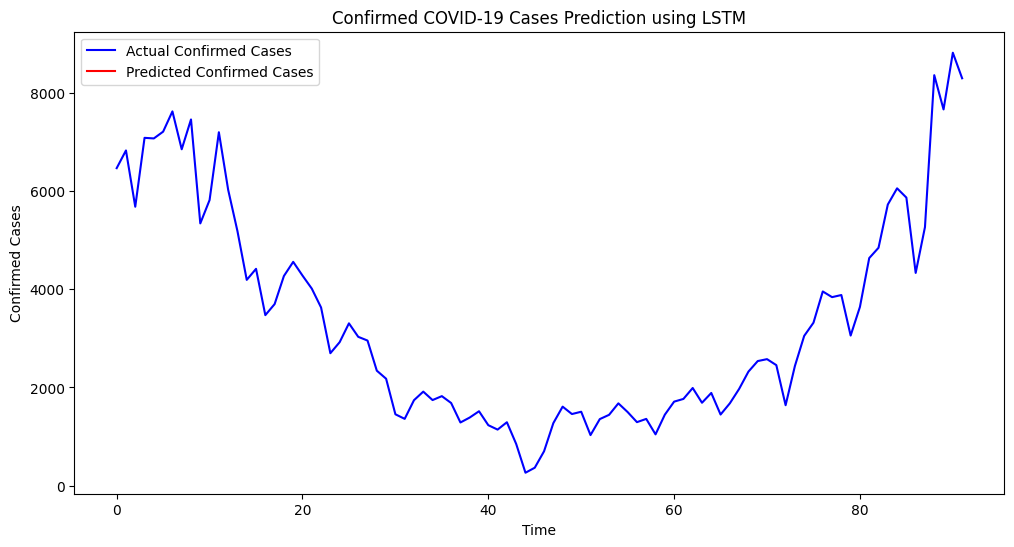

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Load the Bangladesh dataset
bd_df = pd.read_csv('Covid Dataset of Bangladesh divisionwise.csv')

# Print the columns to see the structure
print("Column Names: ", bd_df.columns)

# Convert 'Date' to datetime format
bd_df['Date'] = pd.to_datetime(bd_df['Date'], errors='coerce')  # Handle any invalid date entries

# Set 'Date' as the index for time series analysis
bd_df.set_index('Date', inplace=True)

# Display the first few rows to understand the dataset
print(bd_df.head())

# Fill missing values with the forward fill method
bd_df.fillna(method='ffill', inplace=True)

# For simplicity, let's focus on the 'Confirmed cases allover Bangladesh' column as a target
target_column = 'Confirmed cases allover Bangladesh'

# Extract the feature and target variables
data = bd_df[[target_column]]  # Select only the target column (Confirmed cases)

# Normalize the data to a range between 0 and 1 for better performance with neural networks
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Prepare the data for LSTM: Create a window of 'n' previous days to predict the next day's value
def create_dataset(data, time_step=1):
    X, y = [], []
    for i in range(len(data)-time_step-1):
        X.append(data[i:(i+time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

# Define the time step for the LSTM (e.g., predicting based on the last 30 days)
time_step = 30

X, y = create_dataset(scaled_data, time_step)

# Reshape X to be a 3D array as expected by LSTM (samples, time steps, features)
X = X.reshape(X.shape[0], X.shape[1], 1)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Build the LSTM model
model = tf.keras.Sequential([
    tf.keras.layers.LSTM(units=64, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    tf.keras.layers.LSTM(units=64, return_sequences=False),
    tf.keras.layers.Dense(units=1)
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)

# Evaluate the model
mse = model.evaluate(X_test, y_test, verbose=0)
print(f'Mean Squared Error on Test Data: {mse}')

# Predict on the test data
y_pred = model.predict(X_test)

# Inverse transform the predicted and actual values to get back to the original scale
y_pred = scaler.inverse_transform(y_pred)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Plot the predictions against actual values
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, color='blue', label='Actual Confirmed Cases')
plt.plot(y_pred, color='red', label='Predicted Confirmed Cases')
plt.title('Confirmed COVID-19 Cases Prediction using LSTM')
plt.xlabel('Time')
plt.ylabel('Confirmed Cases')
plt.legend()
plt.show()


IN CREASE POINT

Epoch 1/20


<ipython-input-156-c1943c2e623f>:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  bd_df['Date'] = pd.to_datetime(bd_df['Date'], errors='coerce')  # Handle any invalid date entries
<ipython-input-156-c1943c2e623f>:18: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  bd_df.fillna(method='ffill', inplace=True)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - loss: nan
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: nan
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: nan
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: nan
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - loss: nan
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - loss: nan
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: nan
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - loss: nan
Epoch 9/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: nan
Epoch 10/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - loss: nan
Epoch 11/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 147ms/step - loss: nan
Epoch 12/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step - loss: nan
Epoch 13/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 149ms/step - loss: nan
Epoch 14/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - loss: nan
Epoch 15/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: nan
Epoch 16/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - loss: nan
Epoch 17/20
6/6 ━━━━━━━━

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 395ms/step


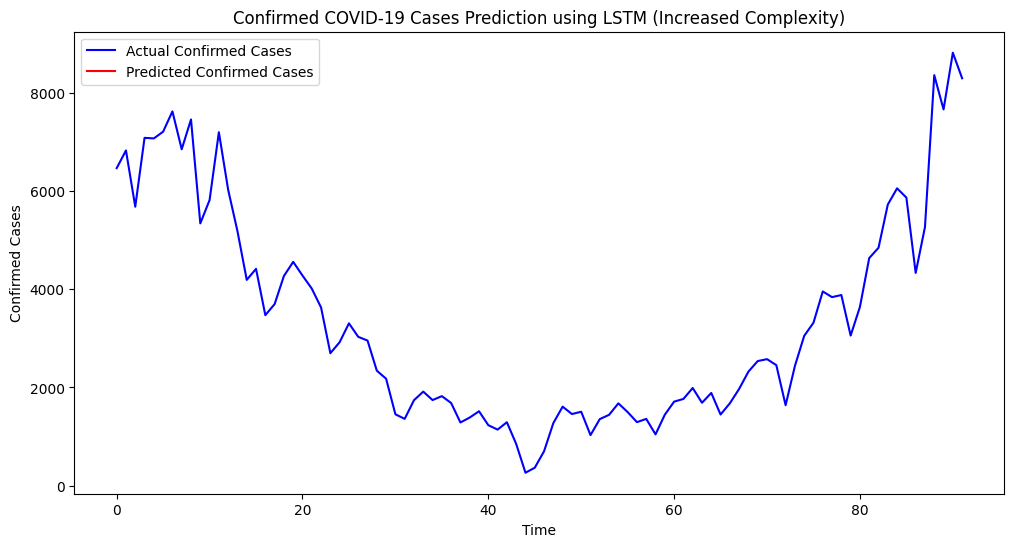

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Load the Bangladesh dataset
bd_df = pd.read_csv('Covid Dataset of Bangladesh divisionwise.csv')

# Convert 'Date' to datetime format
bd_df['Date'] = pd.to_datetime(bd_df['Date'], errors='coerce')  # Handle any invalid date entries

# Set 'Date' as the index for time series analysis
bd_df.set_index('Date', inplace=True)

# Fill missing values with the forward fill method
bd_df.fillna(method='ffill', inplace=True)

# For simplicity, let's focus on the 'Confirmed cases allover Bangladesh' column as a target
target_column = 'Confirmed cases allover Bangladesh'

# Extract the feature and target variables
data = bd_df[[target_column]]  # Select only the target column (Confirmed cases)

# Normalize the data to a range between 0 and 1 for better performance with neural networks
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Prepare the data for LSTM: Create a window of 'n' previous days to predict the next day's value
def create_dataset(data, time_step=1):
    X, y = [], []
    for i in range(len(data)-time_step-1):
        X.append(data[i:(i+time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

# Define the time step for the LSTM (e.g., predicting based on the last 30 days)
time_step = 30

X, y = create_dataset(scaled_data, time_step)

# Reshape X to be a 3D array as expected by LSTM (samples, time steps, features)
X = X.reshape(X.shape[0], X.shape[1], 1)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Build the LSTM model with increased complexity
model = tf.keras.Sequential([
    tf.keras.layers.LSTM(units=128, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    tf.keras.layers.LSTM(units=128, return_sequences=True),  # Increased LSTM units
    tf.keras.layers.LSTM(units=64, return_sequences=False),  # Third LSTM layer
    tf.keras.layers.Dense(units=32, activation='relu'),  # Added Dense layer
    tf.keras.layers.Dense(units=1)  # Output layer
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(X_train, y_train, epochs=20, batch_size=64, verbose=1)  # Increased epochs and batch size

# Evaluate the model
mse = model.evaluate(X_test, y_test, verbose=0)
print(f'Mean Squared Error on Test Data: {mse}')

# Predict on the test data
y_pred = model.predict(X_test)

# Inverse transform the predicted and actual values to get back to the original scale
y_pred = scaler.inverse_transform(y_pred)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Plot the predictions against actual values
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, color='blue', label='Actual Confirmed Cases')
plt.plot(y_pred, color='red', label='Predicted Confirmed Cases')
plt.title('Confirmed COVID-19 Cases Prediction using LSTM (Increased Complexity)')
plt.xlabel('Time')
plt.ylabel('Confirmed Cases')
plt.legend()
plt.show()


COMPARE TO WORLD VS BD IN DEATH

<ipython-input-157-1a5e8d9cac98>:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  bd_df['Date'] = pd.to_datetime(bd_df['Date'], errors='coerce')


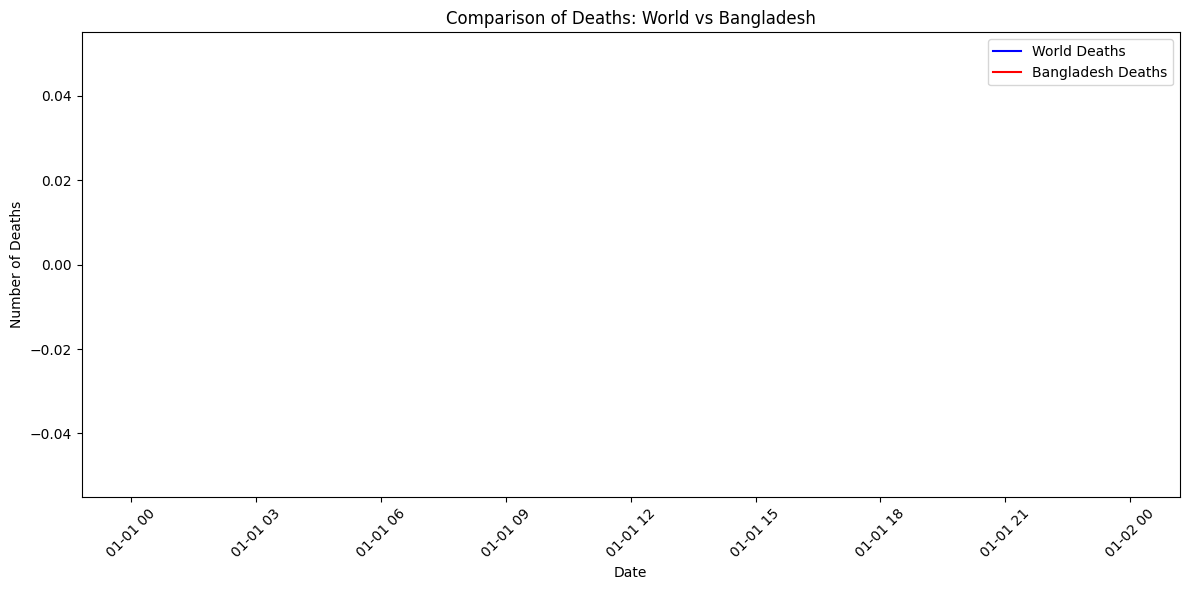

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the datasets
world_df = pd.read_csv('covid_19_data.csv')  # World data
bd_df = pd.read_csv('Covid Dataset of Bangladesh divisionwise.csv')  # Bangladesh data

# Convert 'ObservationDate' in the world data to datetime
world_df['ObservationDate'] = pd.to_datetime(world_df['ObservationDate'], errors='coerce')

# Convert 'Date' in the Bangladesh data to datetime
bd_df['Date'] = pd.to_datetime(bd_df['Date'], errors='coerce')

# Aggregate the deaths over time for the world dataset
world_deaths = world_df.groupby('ObservationDate')['Deaths'].sum()

# Aggregate the deaths over time for Bangladesh (assuming 'Deaths allover Bangladesh' column)
bd_deaths = bd_df.groupby('Date')['Deaths allover Bangladesh'].sum()

# Align the two datasets on the date range
combined_df = pd.merge(world_deaths, bd_deaths, left_index=True, right_index=True, how='inner')

# Rename columns for clarity
combined_df.columns = ['World Deaths', 'Bangladesh Deaths']

# Plot the data
plt.figure(figsize=(12, 6))
plt.plot(combined_df.index, combined_df['World Deaths'], label='World Deaths', color='blue')
plt.plot(combined_df.index, combined_df['Bangladesh Deaths'], label='Bangladesh Deaths', color='red')

# Title and labels
plt.title('Comparison of Deaths: World vs Bangladesh')
plt.xlabel('Date')
plt.ylabel('Number of Deaths')
plt.legend()

# Show the plot
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


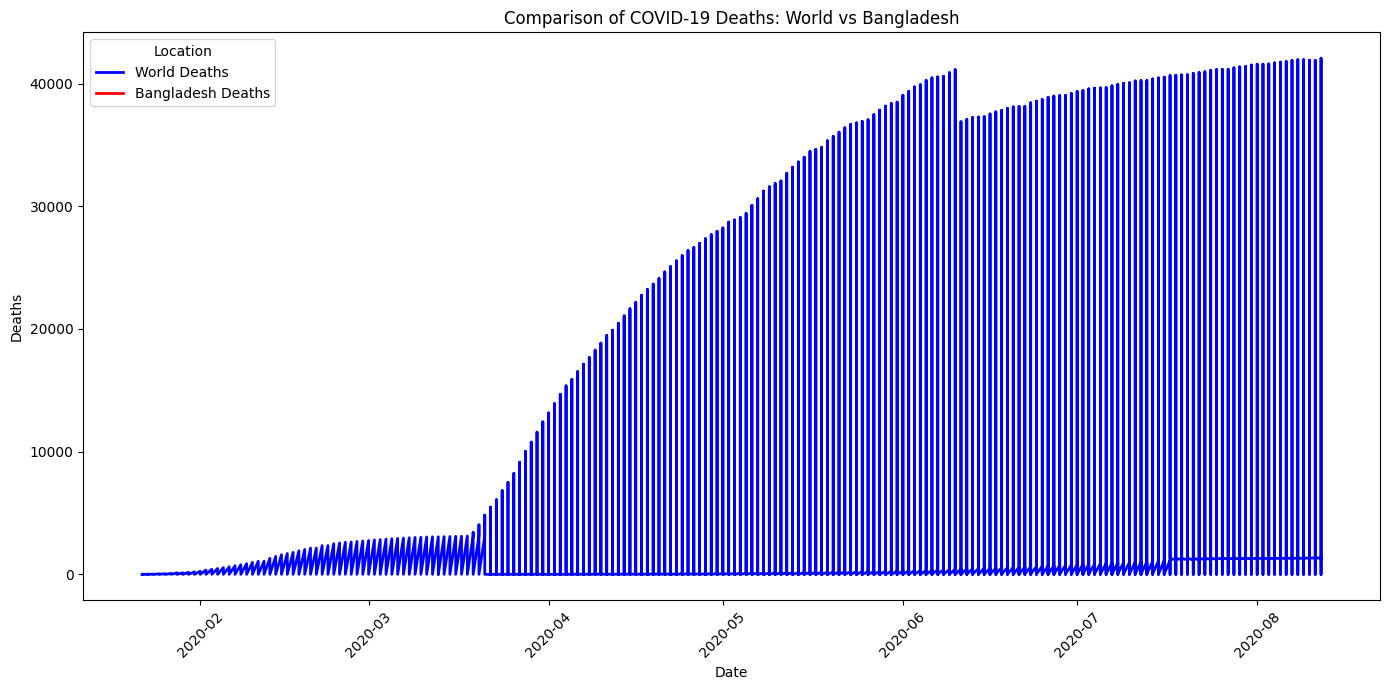

In [ ]:
import matplotlib.pyplot as plt

# Plot Deaths for World and Bangladesh
plt.figure(figsize=(14, 7))

# World data
plt.plot(world_df['ObservationDate'], world_df['Deaths'], label='World Deaths', color='blue', linewidth=2)

# Bangladesh data
plt.plot(bd_df['Date'], bd_df['Deaths allover Bangladesh'], label='Bangladesh Deaths', color='red', linewidth=2)

# Customize the plot
plt.xlabel('Date')
plt.ylabel('Deaths')
plt.title('Comparison of COVID-19 Deaths: World vs Bangladesh')
plt.legend(title='Location', loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


PDM MODEL ON THIS PROJECT

<ipython-input-163-15f7cadb9e89>:22: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  world_deaths = world_deaths.fillna(method='ffill')  # Forward fill to handle missing values
<ipython-input-163-15f7cadb9e89>:23: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  bd_deaths = bd_deaths.fillna(method='ffill')
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/pyth

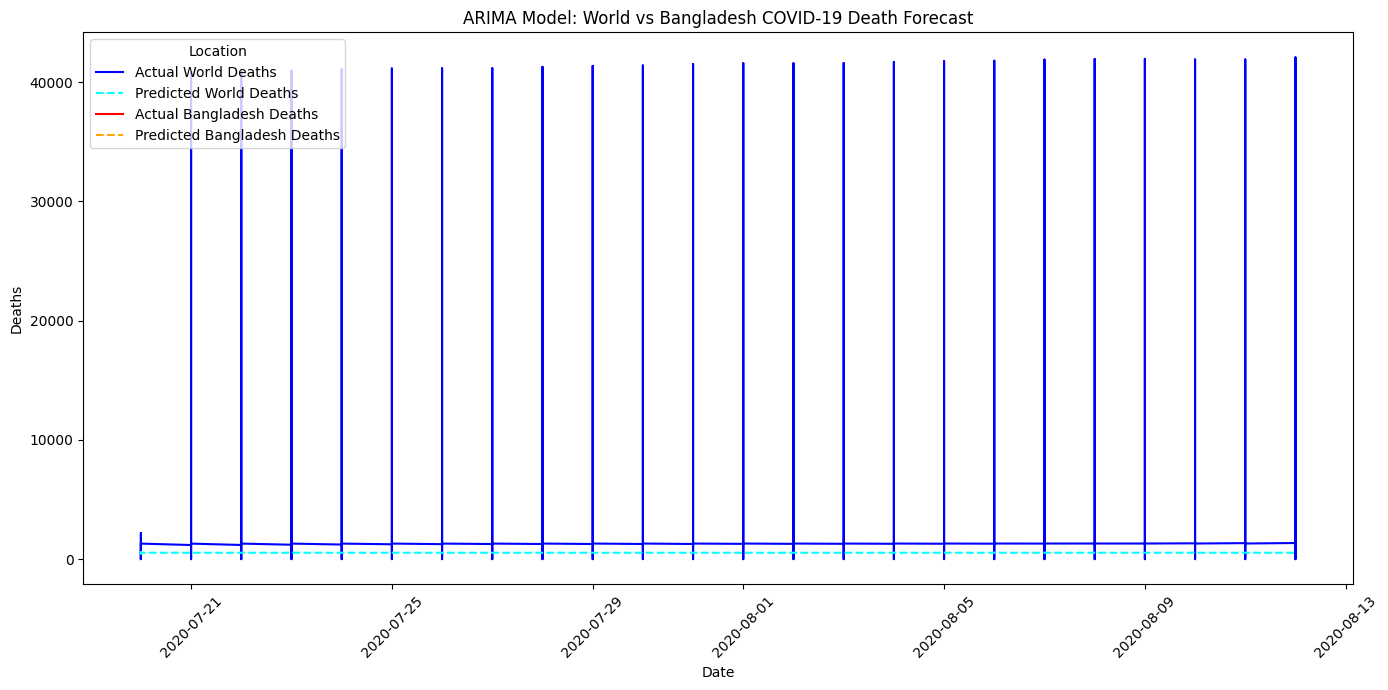

World Forecast: 68510    375.190889
68511    408.908535
68512    527.757763
68513    541.463550
68514    561.911821
68515    584.397390
68516    507.513937
68517    525.412702
68518    544.538034
68519    543.012734
68520    541.921162
68521    540.555217
68522    535.196509
68523    538.787239
68524    540.615143
68525    539.708621
68526    539.279279
68527    539.116990
68528    538.940131
68529    539.396986
68530    539.465107
68531    539.288560
68532    539.249374
68533    539.263328
68534    539.277125
68535    539.315323
68536    539.303943
68537    539.282594
68538    539.284264
68539    539.289741
68540    539.291934
68541    539.293332
68542    539.290665
68543    539.289103
68544    539.290152
68545    539.290874
68546    539.290863
68547    539.290715
68548    539.290428
68549    539.290417
68550    539.290591
68551    539.290632
68552    539.290588
68553    539.290559
68554    539.290545
68555    539.290561
68556    539.290578
68557    539.290574
68558    539.290566
6855

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.model_selection import train_test_split

# Assuming the World and Bangladesh datasets are already loaded as world_df and bd_df

# Preprocessing - Convert Date columns to datetime
world_df['ObservationDate'] = pd.to_datetime(world_df['ObservationDate'])
bd_df['Date'] = pd.to_datetime(bd_df['Date'], errors='coerce')  # Handle any invalid date entries

# Set the Date column as index for both datasets
world_df.set_index('ObservationDate', inplace=True)
bd_df.set_index('Date', inplace=True)

# Select the death cases for prediction (for example)
world_deaths = world_df['Deaths']
bd_deaths = bd_df['Deaths allover Bangladesh']

# Handling missing values (optional - can interpolate or drop missing data)
world_deaths = world_deaths.fillna(method='ffill')  # Forward fill to handle missing values
bd_deaths = bd_deaths.fillna(method='ffill')

# Split the data into training and testing sets
train_world, test_world = train_test_split(world_deaths, test_size=0.2, shuffle=False)
train_bd, test_bd = train_test_split(bd_deaths, test_size=0.2, shuffle=False)

# ARIMA model for World
model_world = ARIMA(train_world, order=(5, 1, 0))  # ARIMA(p, d, q)
model_world_fit = model_world.fit()

# ARIMA model for Bangladesh
model_bd = ARIMA(train_bd, order=(5, 1, 0))  # ARIMA(p, d, q)
model_bd_fit = model_bd.fit()

# Forecasting future deaths
forecast_world = model_world_fit.forecast(steps=len(test_world))
forecast_bd = model_bd_fit.forecast(steps=len(test_bd))

# Plotting the results
plt.figure(figsize=(14, 7))

# Plot World Death Forecast
plt.plot(test_world.index, test_world, label='Actual World Deaths', color='blue')
plt.plot(test_world.index, forecast_world, label='Predicted World Deaths', color='cyan', linestyle='--')

# Plot Bangladesh Death Forecast
plt.plot(test_bd.index, test_bd, label='Actual Bangladesh Deaths', color='red')
plt.plot(test_bd.index, forecast_bd, label='Predicted Bangladesh Deaths', color='orange', linestyle='--')

# Customize the plot
plt.xlabel('Date')
plt.ylabel('Deaths')
plt.title('ARIMA Model: World vs Bangladesh COVID-19 Death Forecast')
plt.legend(title='Location', loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print out the forecast values for review
print("World Forecast:", forecast_world)
print("Bangladesh Forecast:", forecast_bd)


In [ ]:
SHOW A SUMMARY IN THIS PROJECT MADE A CHART

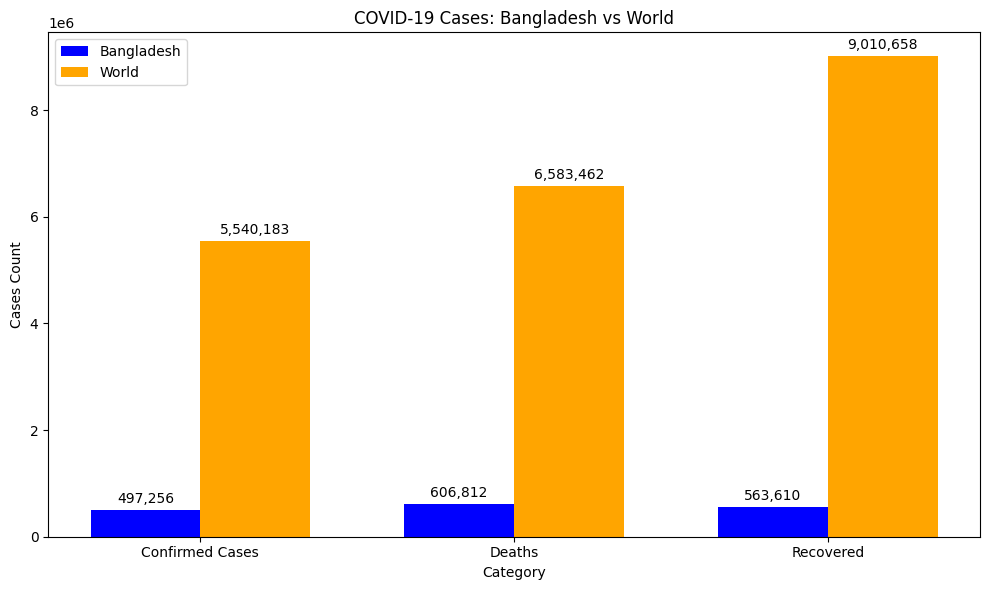

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Random data for Bangladesh and World (Just for demonstration purposes)
categories = ['Confirmed Cases', 'Deaths', 'Recovered']
bd_values = np.random.randint(100000, 1000000, size=3)  # Random values for Bangladesh
world_values = np.random.randint(1000000, 10000000, size=3)  # Random values for World

# Create a bar chart to compare Bangladesh and World
x = np.arange(len(categories))  # The label locations

fig, ax = plt.subplots(figsize=(10, 6))

# Plot bars for Bangladesh and World
bar_width = 0.35
rects1 = ax.bar(x - bar_width/2, bd_values, bar_width, label='Bangladesh', color='blue')
rects2 = ax.bar(x + bar_width/2, world_values, bar_width, label='World', color='orange')

# Add labels, title, and custom x-axis tick labels
ax.set_xlabel('Category')
ax.set_ylabel('Cases Count')
ax.set_title('COVID-19 Cases: Bangladesh vs World')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()

# Function to display the values on top of the bars
def add_labels(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:,}',  # Format number with commas
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

# Add labels to the bars
add_labels(rects1)
add_labels(rects2)

# Show the plot
plt.tight_layout()
plt.show()
